<a href="https://colab.research.google.com/github/Vaishnavi688/Customer_Segmentation_Kmeans/blob/main/Mini_pro_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (1).csv


In [ ]:
data = pd.read_csv("Mall_Customers.csv")

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

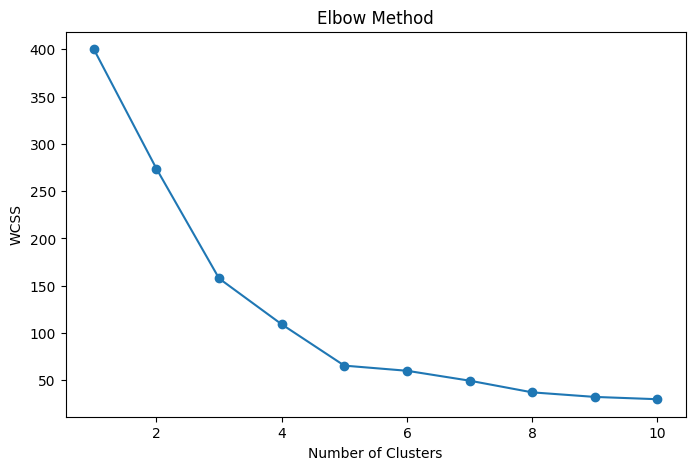

In [ ]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

In [ ]:
data['Cluster'] = y_kmeans
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


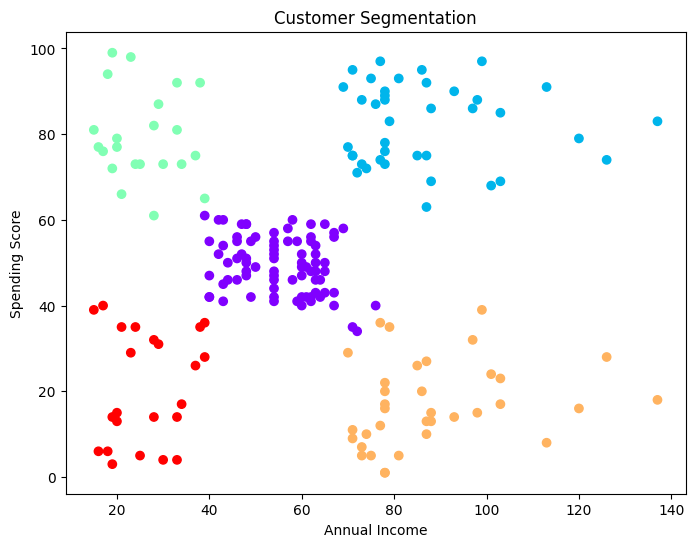

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(
    data['Annual Income (k$)'],
    data['Spending Score (1-100)'],
    c=data['Cluster'],
    cmap='rainbow'
)

plt.title('Customer Segmentation')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')

plt.show()

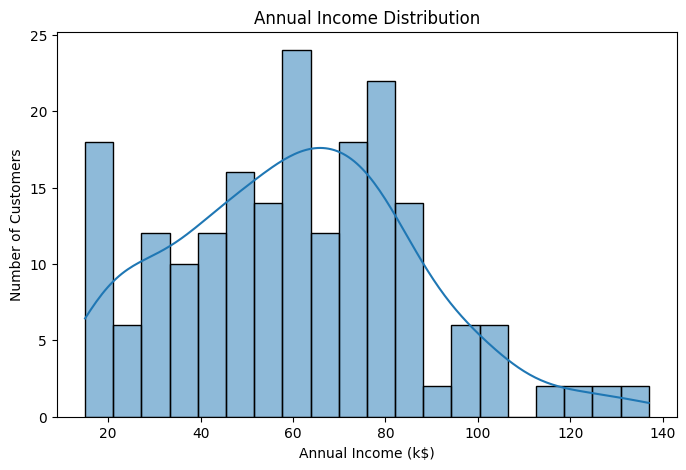

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data['Annual Income (k$)'], bins=20, kde=True)

plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Number of Customers')

plt.show()

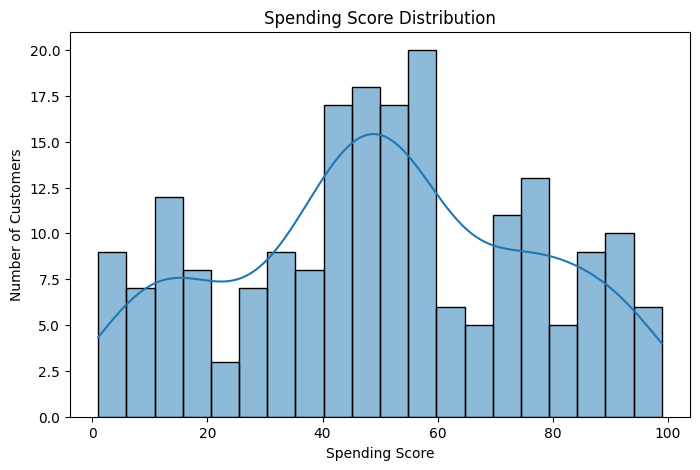

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data['Spending Score (1-100)'], bins=20, kde=True)

plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')
plt.ylabel('Number of Customers')

plt.show()

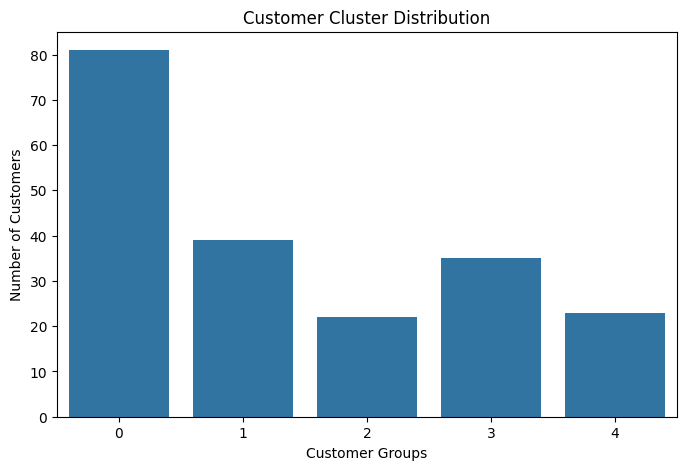

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Cluster', data=data)

plt.title('Customer Cluster Distribution')
plt.xlabel('Customer Groups')
plt.ylabel('Number of Customers')

plt.show()

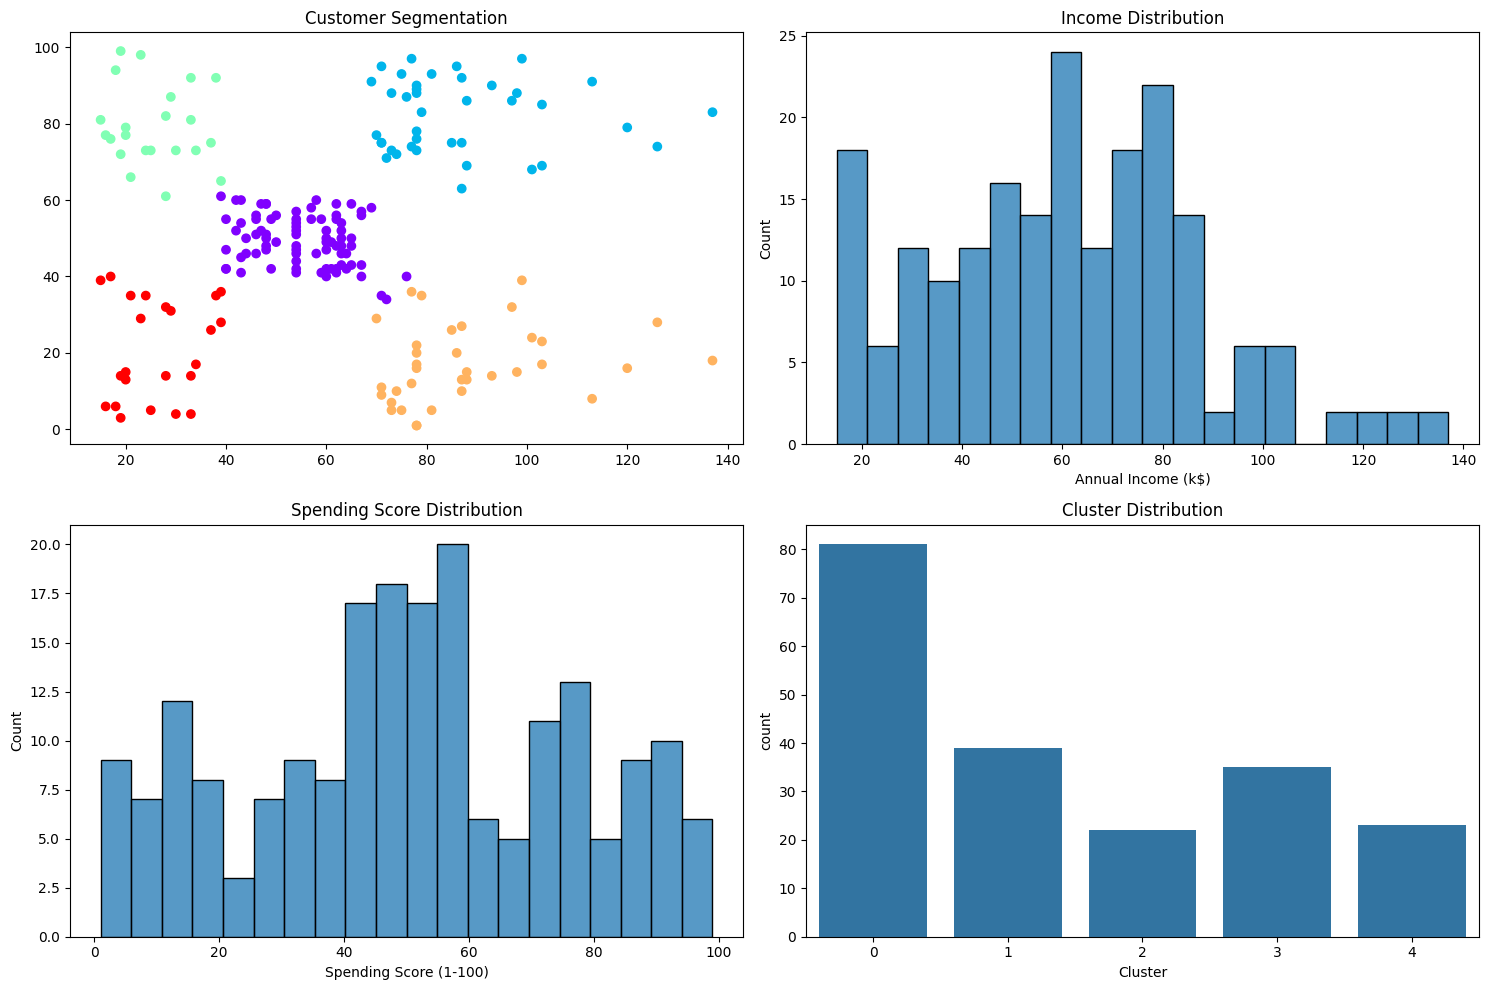

In [ ]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.scatter(data['Annual Income (k$)'],
            data['Spending Score (1-100)'],
            c=data['Cluster'],
            cmap='rainbow')
plt.title('Customer Segmentation')

plt.subplot(2,2,2)
sns.histplot(data['Annual Income (k$)'], bins=20)
plt.title('Income Distribution')

plt.subplot(2,2,3)
sns.histplot(data['Spending Score (1-100)'], bins=20)
plt.title('Spending Score Distribution')

plt.subplot(2,2,4)
sns.countplot(x='Cluster', data=data)
plt.title('Cluster Distribution')

plt.tight_layout()
plt.show()

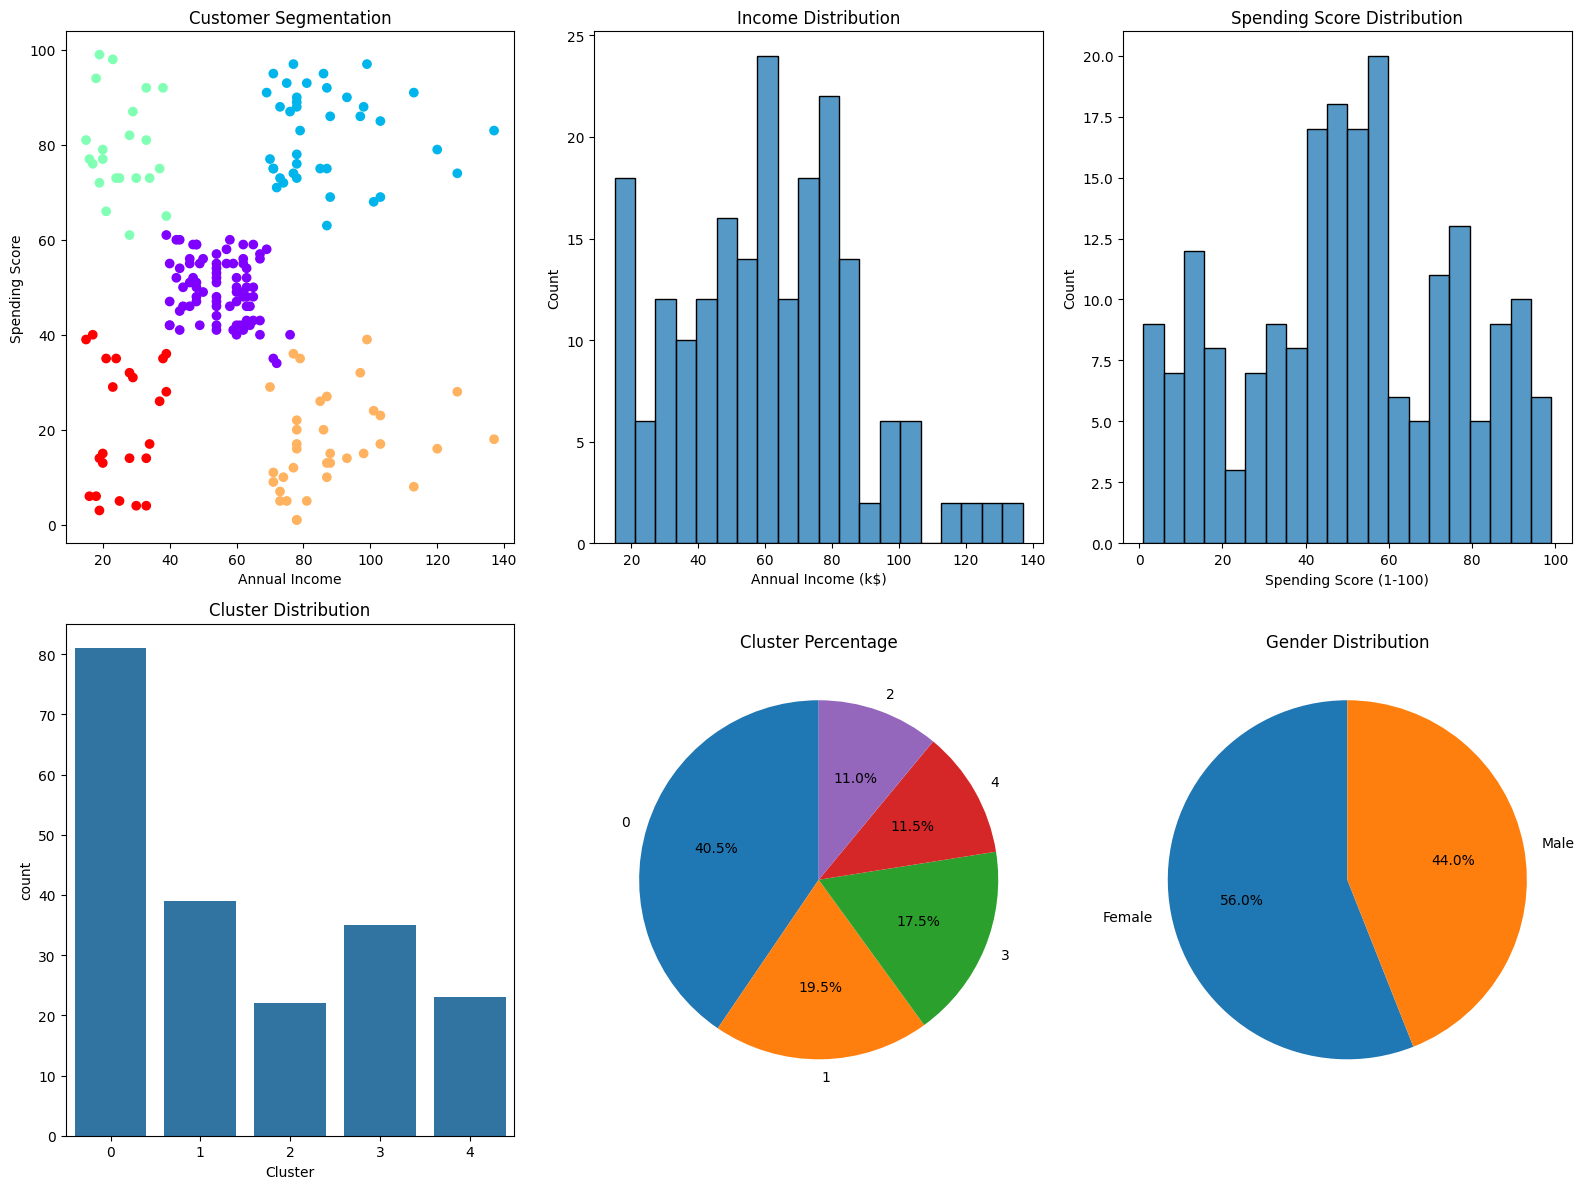

In [ ]:
plt.figure(figsize=(16,12))

# 1. Customer Segmentation Scatter Plot
plt.subplot(2,3,1)
plt.scatter(
    data['Annual Income (k$)'],
    data['Spending Score (1-100)'],
    c=data['Cluster'],
    cmap='rainbow'
)
plt.title('Customer Segmentation')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')


# 2. Annual Income Distribution
plt.subplot(2,3,2)
sns.histplot(data['Annual Income (k$)'], bins=20)
plt.title('Income Distribution')


# 3. Spending Score Distribution
plt.subplot(2,3,3)
sns.histplot(data['Spending Score (1-100)'], bins=20)
plt.title('Spending Score Distribution')


# 4. Cluster Count Chart
plt.subplot(2,3,4)
sns.countplot(x='Cluster', data=data)
plt.title('Cluster Distribution')


# 5. Customer Cluster Pie Chart
plt.subplot(2,3,5)
data['Cluster'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Cluster Percentage')
plt.ylabel('')


# 6. Gender Distribution Pie Chart (Optional)
plt.subplot(2,3,6)
data['Gender'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Gender Distribution')
plt.ylabel('')

plt.tight_layout()
plt.show()
